In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py

from astropy.convolution import Gaussian1DKernel, convolve

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False


In [5]:
data_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5"


In [8]:
with h5py.File(data_path, "r") as f:
    print("Datasets in file:")
    for k in f.keys():
        print(f"  {k}", f[k].shape, f[k].dtype)

    wave = f["WAVE"][:]         
    flux = f["FLUX"][:]  
    flux_ivar = f["FLUX_IVAR"][:]       
    targetid = f["TARGETID"][:] 
    zreds = f["Z"][:] 
    


Datasets in file:
  FLUX (368807, 7781) float32
  FLUX_IVAR (368807, 7781) float32
  TARGETID (368807,) int64
  WAVE (7781,) float32
  Z (368807,) float32


In [40]:
tgid_plot = 39627357580956928

flux_plot = flux[targetid == tgid_plot][0]
flux_ivar_plot = flux_ivar[targetid == tgid_plot][0]
zred_plot = zreds[targetid == tgid_plot][0]

wave_rest = wave/(1+zred_plot)

/tmp/ipykernel_1255936/3107025826.py:3: RuntimeWarning: divide by zero encountered in true_divide
  plt.plot(wave_rest,np.sqrt(1/flux_ivar_plot), lw=0.5,color = "darkorange",alpha=0.5)


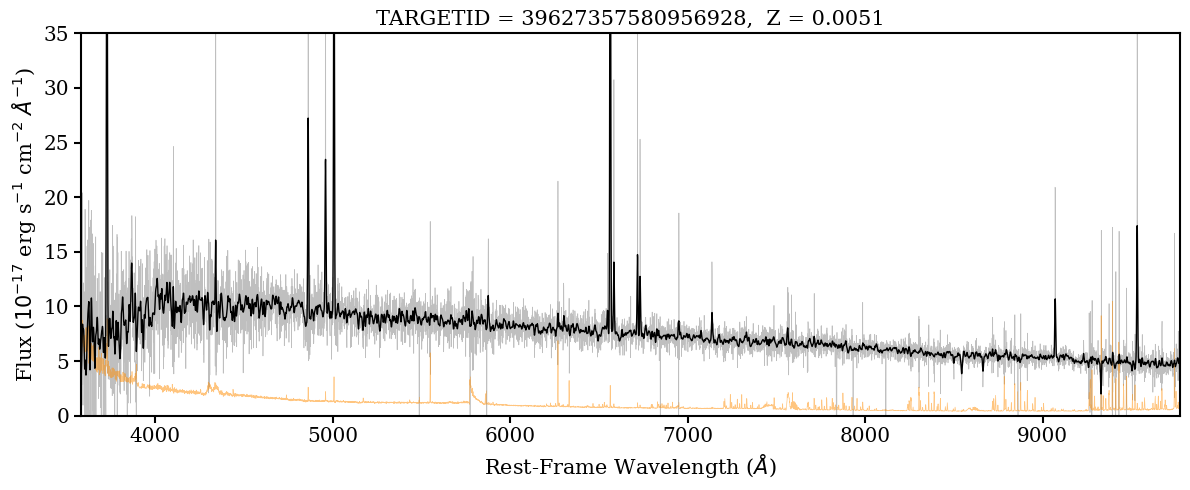

In [59]:

plt.figure(figsize=(12, 5))
plt.plot(wave_rest,flux_plot, lw=0.5,color = "gray",alpha=0.5)
plt.plot(wave_rest,np.sqrt(1/flux_ivar_plot), lw=0.5,color = "darkorange",alpha=0.5)

##smooth the spectra

kernel = Gaussian1DKernel(stddev=3)
good = (flux_ivar_plot > 0)
flux_smooth = convolve(flux_plot[good], kernel)

plt.plot(wave_rest[good],flux_smooth, lw=1,color = "k",alpha=1)

plt.xlabel(r"Rest-Frame Wavelength ($\AA$)",fontsize = 15)
plt.ylabel(r"Flux ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)",fontsize = 15)
plt.title(f"TARGETID = {tgid_plot},  Z = {zred_plot:.4f}",fontsize = 15)
plt.xlim([np.min(wave_rest),np.max(wave_rest)])
plt.ylim([0,35])
plt.tight_layout()
plt.show()

In [ ]:
## add code to read the nnmf coefficents and plot the template fit?